# FWI projections 2026-2045 -- Seville, SSP2-4.5

**SECS -- Southern Europe Climate Study** -- Seville (Guadalquivir basin)

Ports `FWI_projections_last_2.ipynb` (the SSP5-8.5 version, which covers both Seville and Larissa) to
the CMIP6 SSP2-4.5 pull, **scoped to Seville only**. Larissa is excluded deliberately, not by omission:
the SSP5-8.5 notebook itself computes a Larissa run but flags it "NOT VALIDATED -- no CEMS overlap
available" throughout, since Larissa has no CEMS ground-truth record to validate the FWI implementation
against (confirmed here too -- only `Historical/data/seville_fwi_daily_1990_2025.csv` exists, no
Larissa equivalent). Larissa's fire-danger numbers were never used as a validated climate indicator for
that city elsewhere in this project (see `larissa_cmip6_projection_eda.ipynb` Section 17), so this port
doesn't compute them at all rather than producing unvalidated numbers with nothing to attach them to.

Uses **CMCC-ESM2** daily fields, grid-averaged and bias-corrected against ERA5 by the existing
pipeline -- same model as the SSP5-8.5 FWI notebook, deliberately, so the Section 1 validation (FWI
computed on ERA5, checked against CEMS) is identical to that notebook's own -- it depends only on ERA5
and CEMS, neither of which vary by projection scenario, so it is not recomputed differently here, just
re-run for consistency.

**One difference from the SSP5-8.5 notebook worth stating plainly: the bias-corrected source file
here runs 2026-2045 only, not 2026-2061.** The SSP5-8.5 notebook uses `bias_correct_cmip6_projection.py`'s
standalone 2026-2061 extended output and truncates it to 2045; no equivalent 2046-2061 raw pull exists
for SSP2-4.5, so this notebook uses `seville_cmip6_projection_eda.ipynb`'s own inline 2026-2045
bias-corrected export directly (`../eda_outputs/seville/seville_projection_daily_biascorrected_2026_2045.csv`).
Per the SSP5-8.5 notebook's own reasoning (EDCDFm computes each future day's percentile against the
model's *historical* distribution, so a day's correction doesn't depend on which other future days are
in the file), this is equivalent to truncating a longer file -- not a methodological shortcut.

## Method

| Stage | Where it happens |
|---|---|
| Raw CMIP6 pull, per grid point | `pull_cmip6_projections_ssp245.py` |
| 4-cell grid average, K to degC, RH derivation | `cmip6_grid_processing.py` |
| EDCDFm bias correction vs ERA5, per month | `seville_cmip6_projection_eda.ipynb` Section 12 |
| FWI computation | `fwi_from_daily.py` (imported below) |

## Inputs, and why each is the right one

All four FWI drivers come from the bias-corrected file:

| FWI needs | Column | Note |
|---|---|---|
| noon temperature | `tmax_c` | close to the noon-to-mid-afternoon peak |
| noon relative humidity | `rh_min_percent` | derived at `tasmax`, so it is the daily *minimum* RH |
| noon wind | `wind_avg` | **real projected wind** -- CMCC-ESM2 publishes daily `sfcWind` |
| 24 h precipitation | `precip_mm_day` | multiplicative correction, guards against negatives |

**RH is the minimum, not the mean** -- same reasoning as the SSP5-8.5 notebook: daily-mean RH would
overstate summer humidity and suppress projected fire danger. The variable is bias-corrected in its
own right rather than rescaled after the fact.

## What is reported, and what is not

`days_fwi_gt30` -- annual days above the C3S **high fire danger** threshold -- is the headline,
matching the SSP5-8.5 notebook. **Persistence metrics are not reported for the projection**, for the
same reason established there: longest consecutive high-danger run and 5-day spell count don't
reproduce well against CEMS (Section 2 re-confirms this, since it's an ERA5-vs-CEMS check,
scenario-independent).

## 0. Setup

Paths resolve against the project root rather than the current working directory. The previous run
of this notebook reported every input as MISSING and imported `fwi_from_daily` from `Downloads`,
which is the signature of a kernel started outside the project. `find_root()` walks upward looking
for a marker file so the notebook behaves the same wherever it is launched from.

In [1]:
import os
import re
import sys
import glob
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
from IPython.display import display          # explicit: nbconvert has no builtin

warnings.filterwarnings("ignore", category=FutureWarning)


# ---------------------------------------------------------------- project root
MARKERS = ("fwi_from_daily.py", "project_summary.md", ".git")


def find_root(start=None, markers=MARKERS, max_up=6):
    """Walk upward from `start` until a directory containing any marker is found."""
    here = Path(start or os.getcwd()).resolve()
    for cand in [here, *here.parents][:max_up + 1]:
        if any((cand / m).exists() for m in markers):
            return cand
    return here


# Override here if the kernel starts somewhere unexpected:
ROOT = find_root()
os.chdir(ROOT)

DATA = ROOT / "Projected_SSP2-4.5" / "data"
FIGS = ROOT / "Projected_SSP2-4.5" / "figures"
HIST_DATA = ROOT / "Historical" / "data"
DATA.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

print("root :", ROOT)
print("data :", DATA, "|", "exists" if DATA.exists() else "MISSING")
if not any((ROOT / m).exists() for m in MARKERS):
    print("WARNING: no project marker found - ROOT may be wrong. Set it manually above.")


# ---------------------------------------------------------------- sites
# Seville only -- Larissa has no CEMS record to validate against (confirmed: no
# larissa_fwi_daily_*.csv exists in Historical/data/), and its FWI is not used as a
# validated climate indicator anywhere else in this project. See the intro above.
SITES = {
    "seville": {
        "lat": 37.39, "colour": "#E8A33D", "label": "Seville",
        "era5": ROOT / "Historical/eda_outputs/seville/seville_daily.csv",
        "cems": HIST_DATA / "seville_fwi_daily_1990_2025.csv",
    },
}

SCENARIO = "ssp245"
SCENARIO_LABEL = "SSP2-4.5"
MODEL = "CMCC-ESM2"
MODEL_TAG = "cmcc_esm2"        # goes into every output filename - see note in section 4

# Bias-corrected projection column names
PROJ_MAP = {"tasmax": "tmax_c", "pr": "precip_mm_day"}
PROJ_RH, PROJ_WIND = "rh_min_percent", "wind_avg"

# ERA5 EDA-output column names (same names, conveniently)
ERA5_MAP = {"tasmax": "tmax_c", "pr": "precip_mm_scaled"}
ERA5_RH, ERA5_WIND = "rh_min_percent", "wind_avg"

# Danger thresholds. EFFIS class edges are the six-band scale used on the EFFIS
# maps; C3S indicator products report against the class mid-points instead.
EFFIS_EDGES = {"very low": 0.0, "low": 5.2, "moderate": 11.2, "high": 21.3,
               "very high": 38.0, "extreme": 50.0, "very extreme": 70.0}
C3S_THRESHOLDS = {"moderate": 15.0, "high": 30.0, "very high": 45.0}

FWI_THRESHOLD = C3S_THRESHOLDS["high"]      # 30.0 - the headline
SPINUP_DAYS = 365
PROJ_START, PROJ_END = 2026, 2045           # this scenario's source file already stops at 2045
BASE_START, BASE_END = 1991, 2020           # WMO normal, matches the ERA5 reference
PERIODS = {"2026-2035": (2026, 2035), "2036-2045": (2036, 2045),
           "2026-2045": (2026, 2045)}

print("pandas", pd.__version__, "| numpy", np.__version__)
print(f"headline threshold FWI > {FWI_THRESHOLD:.0f} (C3S 'high', mid-point of EFFIS 21.3-38.0)")

root : /Users/karina/neuefische_course/week-14/capstone_project/SECS_capstone_project
data : /Users/karina/neuefische_course/week-14/capstone_project/SECS_capstone_project/Projected_SSP2-4.5/data | exists
pandas 3.0.5 | numpy 2.4.6
headline threshold FWI > 30 (C3S 'high', mid-point of EFFIS 21.3-38.0)


In [2]:
sys.path.insert(0, str(ROOT / "scripts"))
import fwi_from_daily as F
import importlib; importlib.reload(F)

import xclim
print("xclim  ", xclim.__version__)
print("module :", F.__file__)

# The previous run loaded this module from Downloads. Fail loudly rather than
# silently computing FWI with a stale copy.
mod_path = Path(F.__file__).resolve()
if ROOT not in mod_path.parents:
    raise RuntimeError(
        f"fwi_from_daily loaded from {mod_path}, outside the project root {ROOT}.\n"
        f"Restart the kernel from the project directory, or fix ROOT above.")

for fn in ("prepare", "compute_fwi", "annual_indicators", "DEFAULT_MAP"):
    assert hasattr(F, fn), f"fwi_from_daily.py is missing {fn}"
print("API    : prepare, compute_fwi, annual_indicators, DEFAULT_MAP  OK")

xclim   0.61.1
module : /Users/karina/neuefische_course/week-14/capstone_project/SECS_capstone_project/scripts/fwi_from_daily.py
API    : prepare, compute_fwi, annual_indicators, DEFAULT_MAP  OK


### 0.1 Guards

Three failure modes this pipeline is exposed to, each silent if unchecked:

**Unit slips.** FWI takes °C, %, km/h and mm/day. ERA5 and CMIP6 disagree on every one of those
conventions (`tp × 1000` against `kg m⁻² s⁻¹ × 86400`, K against °C), and a wrong unit does not
raise — it produces a plausible-looking series with the wrong answer. Range checks alone are not
enough: precipitation left in `kg m⁻² s⁻¹` reads ~1e-5, comfortably inside any sane mm/day window,
so the check is on the annual total instead. Wind in km/h mislabelled as m/s survives a range check
too, so that one is tested on the median.

**Calendar gaps.** Several CMIP6 models run a 365-day calendar and never emit 29 February. FWI
integrates sequentially and the drought code carries months of memory, so a missing day is not a
missing row — it shifts the moisture accounting for everything after it. Inputs are reindexed onto
a complete daily axis before integration.

**BUI → DMC inversion.** The build-up index is piecewise in DMC. The closed-form inverse only holds
on the branch where `DMC ≤ 0.4·DC`; applied beyond it, it returns values that are wrong by hundreds
of units. Section 3 solves the full function numerically instead.

In [3]:
SANE = {
    "temp_c":   (-30.0,  60.0, "degrees C (K would read ~250-320)"),
    "rh":       (  0.0, 100.0, "relative humidity in percent"),
    "wind_kmh": (  0.0, 200.0, "wind in km/h (m/s would read ~0-20)"),
    "precip":   (  0.0, 500.0, "precipitation in mm/day"),
}


def check_inputs(df, temp_col, rh_col, wind_col, precip_col,
                 wind_units="m/s", label=""):
    """Return a list of problems. Empty list = inputs look like the right units."""
    problems = []
    w_kmh = pd.to_numeric(df[wind_col], errors="coerce") * (3.6 if wind_units == "m/s" else 1.0)
    for series, key, name in [
        (df[temp_col],   "temp_c",   temp_col),
        (df[rh_col],     "rh",       rh_col),
        (w_kmh,          "wind_kmh", f"{wind_col} (as km/h)"),
        (df[precip_col], "precip",   precip_col),
    ]:
        lo, hi, expect = SANE[key]
        s = pd.to_numeric(series, errors="coerce")
        if s.notna().sum() == 0:
            problems.append(f"{name}: all values missing")
            continue
        if s.min() < lo or s.max() > hi:
            problems.append(f"{name}: range [{s.min():.2f}, {s.max():.2f}] outside "
                            f"[{lo}, {hi}] - expected {expect}")
        if s.isna().mean() > 0.01:
            problems.append(f"{name}: {s.isna().mean():.1%} missing")

    # --- magnitude checks: unit errors that sit inside the range window
    rh = pd.to_numeric(df[rh_col], errors="coerce")
    if rh.max() <= 1.5:
        problems.append(f"{rh_col}: max {rh.max():.3f} - a fraction, not a percentage")

    p = pd.to_numeric(df[precip_col], errors="coerce")
    span = max((df.index[-1] - df.index[0]).days / 365.25, 1e-6)
    annual_mm = float(p.sum()) / span
    if annual_mm < 100:
        problems.append(f"{precip_col}: annual total {annual_mm:.4g} mm/yr implausibly low "
                        f"- CMIP6 kg m-2 s-1 needs x86400, ERA5 tp needs x1000")
    elif annual_mm > 3000:
        problems.append(f"{precip_col}: annual total {annual_mm:.0f} mm/yr implausibly high")

    wmed = float(pd.to_numeric(df[wind_col], errors="coerce").median())
    if wind_units == "m/s" and wmed > 12:
        problems.append(f"{wind_col}: median {wmed:.1f} high for m/s - already km/h?")
    if wind_units == "km/h" and wmed < 5:
        problems.append(f"{wind_col}: median {wmed:.1f} low for km/h - still m/s?")

    tag = f"[{label}] " if label else ""
    if problems:
        print(f"  {tag}INPUT CHECK - {len(problems)} problem(s):")
        for pr in problems:
            print(f"    ! {pr}")
    else:
        print(f"  {tag}input check OK (T {df[temp_col].min():.1f}..{df[temp_col].max():.1f} C, "
              f"RH {rh.min():.0f}..{rh.max():.0f} %, wind median {wmed:.1f} {wind_units}, "
              f"precip {annual_mm:.0f} mm/yr)")
    return problems


def ensure_daily_continuity(df, max_gap=3, label=""):
    """Reindex onto a complete daily axis and interpolate short gaps."""
    df = df[~df.index.duplicated(keep="first")].sort_index()
    full = pd.date_range(df.index.min(), df.index.max(), freq="D")
    missing = full.difference(df.index)
    tag = f"[{label}] " if label else ""
    if len(missing) == 0:
        print(f"  {tag}calendar continuous, {len(df)} days")
        return df, {"inserted": 0, "max_run": 0, "feb29": 0, "still_nan": 0}

    runs, run = [], 1
    for a, b in zip(missing[:-1], missing[1:]):
        run = run + 1 if (b - a).days == 1 else (runs.append(run) or 1)
    runs.append(run)

    out = df.reindex(full)
    num = out.select_dtypes(include=[np.number]).columns
    out[num] = out[num].interpolate(method="time", limit=max_gap, limit_area="inside")

    # Anything still missing sits inside a gap longer than max_gap. Leaving it NaN
    # is not neutral: F.prepare drops NaN rows, which would silently reopen the
    # discontinuity this function exists to close. Fill from day-of-year climatology
    # and report the count, so the series stays contiguous and the fill is visible.
    clim_filled = int(out[num].isna().any(axis=1).sum())
    if clim_filled:
        doy = out.index.dayofyear
        for c in num:
            clim = out[c].groupby(doy).transform("mean")
            out[c] = out[c].fillna(clim)
        out[num] = out[num].ffill().bfill()

    feb29 = sum(1 for d in missing if (d.month, d.day) == (2, 29))
    rep = {"inserted": len(missing), "max_run": max(runs), "feb29": feb29,
           "clim_filled": clim_filled,
           "still_nan": int(out[num].isna().any(axis=1).sum())}
    print(f"  {tag}inserted {rep['inserted']} missing days "
          f"({feb29} of them 29 Feb -> 365-day model calendar), "
          f"longest gap {rep['max_run']} d")
    if rep["max_run"] > max_gap:
        print(f"    ! gap longer than {max_gap} d: {clim_filled} day(s) filled from "
              f"day-of-year climatology, not interpolation - check the source file")
    return out, rep


def _bui(dmc, dc):
    """van Wagner & Pickett (1985) build-up index, both branches."""
    if dmc <= 0:
        return 0.0
    if dmc <= 0.4 * dc:
        u = 0.8 * dmc * dc / (dmc + 0.4 * dc)
    else:
        u = dmc - (1.0 - 0.8 * dc / (dmc + 0.4 * dc)) * (0.92 + (0.0114 * dmc) ** 1.7)
    return max(u, 0.0)


def invert_bui_to_dmc(bui, dc, dmc_max=1000.0):
    """Recover DMC from BUI and DC. Analytic on branch 1, bracketed root on branch 2.
    BUI increases monotonically with DMC at fixed DC, so the root is unique."""
    if not (np.isfinite(bui) and np.isfinite(dc)) or bui <= 0 or dc <= 0:
        return None, "bui or dc non-positive"
    denom = 0.8 * dc - bui
    if denom > 1e-6:
        cand = 0.4 * dc * bui / denom
        if 0 < cand <= 0.4 * dc:            # branch-1 validity condition
            return float(cand), "analytic (branch 1)"
    f = lambda d: _bui(d, dc) - bui
    lo, hi = 1e-6, max(0.4 * dc, 1.0)
    while f(hi) < 0 and hi < dmc_max:
        hi *= 2.0
    if f(lo) > 0 or f(hi) < 0:
        return None, "no bracket - BUI/DC pair inconsistent"
    try:
        root = brentq(f, lo, hi, xtol=1e-6)
    except (ValueError, RuntimeError) as exc:
        return None, f"solver failed: {exc}"
    return (float(root), "numeric (branch 2)") if 0 < root < dmc_max else (None, "root out of range")


def theil_sen(y):
    """Theil-Sen slope + Kendall tau. Always returns the same keys."""
    y = pd.Series(y).dropna()
    out = dict(slope=np.nan, intercept=np.nan, lo=np.nan, hi=np.nan,
               tau=np.nan, p=np.nan, n=len(y))
    if len(y) < 8:
        return out
    x = np.asarray(y.index, dtype=float)
    slope, intercept, lo, hi = stats.theilslopes(y.values, x, 0.95)
    tau, p = stats.kendalltau(x, y.values)
    out.update(slope=slope, intercept=intercept, lo=lo, hi=hi, tau=tau, p=p)
    return out


def complete_years(df, min_days=360):
    """Drop partial years - a truncated year understates every annual count."""
    counts = df.groupby(df.index.year).size()
    keep = counts[counts >= min_days].index
    return df[df.index.year.isin(keep)], sorted(set(counts.index) - set(keep))


def read_daily(path, date_col=None):
    """Read a daily CSV whose date column is named inconsistently across the project."""
    head = pd.read_csv(path, nrows=1)
    if date_col is None:
        for cand in ("valid_time", "date", "time", "Date", "datetime"):
            if cand in head.columns:
                date_col = cand
                break
        else:
            date_col = head.columns[0]          # unnamed index column
    df = pd.read_csv(path, parse_dates=[date_col]).set_index(date_col).sort_index()
    df.index = pd.DatetimeIndex(df.index).tz_localize(None).normalize()
    df.index.name = "date"
    return df


print("guards defined: check_inputs, ensure_daily_continuity, invert_bui_to_dmc, "
      "theil_sen, complete_years, read_daily")

guards defined: check_inputs, ensure_daily_continuity, invert_bui_to_dmc, theil_sen, complete_years, read_daily


### 0.2 Generate a complete bias-corrected projection file (includes `rh_min_percent`)

`seville_cmip6_projection_eda.ipynb`'s own inline bias correction (Section 12) only corrects the
variables its own hand-built `daily` frame carries -- it explicitly skips `rh_min_percent` (see that
section's own comment: "has no equivalent in this notebook's hand-built `daily` frame... FWI-related
work lives in [the FWI notebook], not here"). FWI needs that variable specifically (the noon-RH proxy,
Section 0 intro), so it isn't usable as this notebook's input directly.

The SSP5-8.5 FWI notebook sidesteps this by reading `bias_correct_cmip6_projection.py`'s **standalone**
output instead, which runs `cmip6_grid_processing.grid_average_daily()` (which does derive
`rh_min_percent`) through the full `VARIABLE_MAP` (which does include it). That script is hardcoded to
SSP5-8.5's paths and its own 2026-2061 extended pull, so rather than parameterizing it, the cell below
reproduces its `fit_and_apply()` logic exactly, retargeted to this scenario's own raw pull and output
path -- same helper functions, same fixed 1990-2014 fitting period, same reused `cmcc_esm2` historical
run. Skips regeneration if the file already exists.

In [4]:
sys.path.insert(0, str(ROOT / "scripts"))
from cmip6_grid_processing import grid_average_daily
from bias_correct_cmip6_projection import (
    _empirical_cdf, _value_to_quantile, _quantile_to_value, VARIABLE_MAP, REF_START, REF_END,
)

for city, cfg in SITES.items():
    src = DATA / f"{city}_cmip6_{SCENARIO}_{PROJ_START}_{PROJ_END}.csv"
    dst = DATA / f"{city}_cmip6_{MODEL_TAG}_{SCENARIO}_{PROJ_START}_{PROJ_END}_biascorrected.csv"
    if dst.exists():
        print(f"[{city}] {dst.name} already exists, skipping regeneration")
        continue
    if not src.exists():
        print(f"[{city}] no raw pull at {src} -- cannot generate bias-corrected file")
        continue

    era5 = pd.read_csv(cfg["era5"], parse_dates=["valid_time"])
    era5["year"] = era5["valid_time"].dt.year
    era5["month"] = era5["valid_time"].dt.month
    era5_ref = era5[era5["year"].between(REF_START, REF_END)]

    hist_src = ROOT / "Projected_SSP5-8.5" / "data" / f"{city}_cmip6_historical_1990_2014.csv"
    model_hist = grid_average_daily(hist_src)
    model_hist_ref = model_hist[model_hist["year"].between(REF_START, REF_END)]

    model_fut = grid_average_daily(src)
    corrected = model_fut.copy()

    for model_col, (era5_col, kind) in VARIABLE_MAP.items():
        for month in range(1, 13):
            obs_vals = era5_ref.loc[era5_ref["month"] == month, era5_col]
            hist_vals = model_hist_ref.loc[model_hist_ref["month"] == month, model_col]
            fut_mask = model_fut["month"] == month
            fut_vals = model_fut.loc[fut_mask, model_col]

            obs_probs, obs_q = _empirical_cdf(obs_vals)
            hist_probs, hist_q = _empirical_cdf(hist_vals)

            tau = np.clip(_value_to_quantile(fut_vals.values, hist_probs, hist_q), 0.0, 1.0)
            obs_at_tau = _quantile_to_value(tau, obs_probs, obs_q)
            hist_at_tau = _quantile_to_value(tau, hist_probs, hist_q)

            if kind == "additive":
                new_vals = fut_vals.values + (obs_at_tau - hist_at_tau)
            else:  # multiplicative -- guards against blow-up when hist_at_tau is near zero
                ratio = np.clip(obs_at_tau / np.clip(hist_at_tau, 1e-3, None), 0.1, 10.0)
                new_vals = np.clip(fut_vals.values * ratio, 0, None)
            corrected.loc[fut_mask, model_col] = new_vals

    corrected.to_csv(dst)
    print(f"[{city}] wrote {dst.name} ({len(corrected):,} rows, columns: {list(corrected.columns)})")

[seville] seville_cmip6_cmcc_esm2_ssp245_2026_2045_biascorrected.csv already exists, skipping regeneration


In [5]:
def find_input(*candidates):
    """First existing path, expanding globs. Returns None if nothing matches."""
    for c in candidates:
        hits = sorted(glob.glob(str(c)))
        if hits:
            return Path(hits[0])
    return None


def inventory(path, note=""):
    if path and Path(path).exists():
        cols = list(pd.read_csv(path, nrows=1).columns)
        print(f"  OK      {Path(path).relative_to(ROOT) if ROOT in Path(path).parents else path}")
        print(f"          {cols}")
        return Path(path)
    print(f"  MISSING {path}{'  ' + note if note else ''}")
    return None


print("ERA5 (validation inputs + baseline reference)")
for city, cfg in SITES.items():
    cfg["era5"] = inventory(find_input(cfg["era5"]))

print("\nCEMS historical FWI (validation target + warm start)")
for city, cfg in SITES.items():
    cfg["cems"] = inventory(find_input(cfg["cems"], HIST_DATA / f"{city}_fwi_daily_*.csv"))
have_cems = {c: SITES[c]["cems"] is not None for c in SITES}

print("\nBias-corrected CMIP6 projections")
PROJ_SRC = {}
for city in SITES:
    PROJ_SRC[city] = inventory(find_input(
        # The complete bias-corrected file generated in 0.2 above (includes rh_min_percent).
        DATA / f"{city}_cmip6_{MODEL_TAG}_{SCENARIO}_{PROJ_START}_{PROJ_END}_biascorrected.csv",
        DATA / f"{city}_cmip6_{MODEL_TAG}_{SCENARIO}_*_biascorrected.csv",
    ))
have_proj = {c: PROJ_SRC[c] is not None for c in SITES}

if not any(have_cems.values()) and not any(have_proj.values()):
    print("\nNothing found. Every downstream cell will skip. Check ROOT above before continuing.")

ERA5 (validation inputs + baseline reference)
  OK      Historical/eda_outputs/seville/seville_daily.csv
          ['valid_time', 'tmax_c', 'tmin_c', 'tmean_c', 'precip_mm', 'precip_mm_scaled', 'wind_avg', 'wind_max', 'd2m_celsius', 'rh_mean_percent', 'rh_min_percent', 'heat_index_max_c', 'dtr_c', 'year', 'month', 'season', 'is_wet']

CEMS historical FWI (validation target + warm start)
  OK      Historical/data/seville_fwi_daily_1990_2025.csv
          ['date', 'city', 'build_up_index', 'drought_code', 'fine_fuel_moisture_code', 'fire_weather_index', 'initial_fire_spread_index']

Bias-corrected CMIP6 projections
  OK      Projected_SSP2-4.5/data/seville_cmip6_cmcc_esm2_ssp245_2026_2045_biascorrected.csv
          ['valid_time', 'tmax_c', 'tmin_c', 'tmean_c', 'precip_mm_day', 'wind_avg', 'rh_mean_percent', 'rh_min_percent', 'year', 'month']


## 1. Validation — FWI on ERA5, against CEMS

The gate. Everything downstream is only meaningful if the implementation reproduces the CEMS
series on inputs where both exist.

Note the input asymmetry, which is worth stating rather than glossing: ERA5 supplies
`rh_min_percent` directly, while the projection derives its equivalent from specific humidity,
pressure and `tasmax` inside `cmip6_grid_processing.py`. Both target daily-minimum RH, so this
validates the FWI implementation but not the RH derivation itself.

In [6]:
validations = {}

for city, cfg in SITES.items():
    if cfg["era5"] is None:
        print(f"[skip] {cfg['label']}: no ERA5 file")
        continue

    print(f"\n=== {cfg['label']} ===")
    era5 = read_daily(cfg["era5"])
    era5, _ = ensure_daily_continuity(era5, label=f"{city} ERA5")
    check_inputs(era5, ERA5_MAP["tasmax"], ERA5_RH, ERA5_WIND, ERA5_MAP["pr"],
                 wind_units="m/s", label=f"{city} ERA5")

    tmp = DATA / f"_tmp_{city}_era5_for_fwi.csv"
    try:
        era5.to_csv(tmp)
        w = F.prepare(daily_csv=str(tmp), wind_csv=None, city=city,
                      colmap={**F.DEFAULT_MAP, **ERA5_MAP},
                      rh_col=ERA5_RH, wind_col=ERA5_WIND, wind_units="m/s")
        v = F.compute_fwi(w, lat=cfg["lat"]).iloc[SPINUP_DAYS:]
    finally:
        tmp.unlink(missing_ok=True)        # survives an exception mid-run

    dst = HIST_DATA / f"{city}_fwi_era5_validation.csv"
    v.to_csv(dst, float_format="%.4f")
    validations[city] = v
    print(f"  -> {dst.name}  ({len(v)} rows, "
          f"{v.index.min().date()} to {v.index.max().date()})")


=== Seville ===
  [seville ERA5] calendar continuous, 13149 days
  [seville ERA5] input check OK (T 2.9..42.9 C, RH 8..95 %, wind median 2.3 m/s, precip 487 mm/yr)
[prepare] humidity: column 'rh_min_percent' used directly
[prepare] wind: column 'wind_avg' x3.6 -> km/h
[prepare] 13149 days  1990-01-01 -> 2025-12-31
          tasmax  mean 23.4 degC
          hurs    mean 48.4 %
          wind    mean 9.0 km/h  (climatology)
          precip  mean 1.33 mm/day


  -> seville_fwi_era5_validation.csv  (12784 rows, 1991-01-01 to 2025-12-31)


In [7]:
PAIRS = [("fwi", "fire_weather_index"),
         ("dc", "drought_code"),
         ("ffmc", "fine_fuel_moisture_code"),
         ("bui", "build_up_index"),
         ("isi", "initial_fire_spread_index")]

validation_tables, overlaps = {}, {}

for city, cfg in SITES.items():
    if city not in validations or not have_cems.get(city):
        print(f"[skip] {cfg['label']}: no CEMS record to validate against")
        continue

    cems = read_daily(cfg["cems"])
    missing_cols = [b for _, b in PAIRS if b not in cems.columns]
    if missing_cols:
        print(f"[warn] {cfg['label']}: CEMS file lacks {missing_cols} - those rows dropped")
    pairs = [(a, b) for a, b in PAIRS if b in cems.columns]

    j = (validations[city][[a for a, _ in pairs]]
         .join(cems[[b for _, b in pairs]], how="inner").dropna())
    if j.empty:
        print(f"[warn] {cfg['label']}: no overlapping dates between ERA5 FWI and CEMS - "
              f"check index alignment (tz, normalisation)")
        continue
    overlaps[city] = j

    t = pd.DataFrame([{"code": a, "r": round(j[a].corr(j[b]), 3),
                       "mine_mean": round(j[a].mean(), 2),
                       "cems_mean": round(j[b].mean(), 2),
                       "bias": round(j[a].mean() - j[b].mean(), 2),
                       "rmse": round(float(np.sqrt(((j[a] - j[b]) ** 2).mean())), 2)}
                      for a, b in pairs]).set_index("code")
    validation_tables[city] = t

    print(f"\n{cfg['label']}: {len(j)} overlapping days "
          f"({j.index.min().date()} -> {j.index.max().date()})")
    display(t)

    r_fwi, b_fwi = t.loc["fwi", "r"], t.loc["fwi", "bias"]
    r_dc = t.loc["dc", "r"] if "dc" in t.index else np.nan
    verdict = "PASS" if (r_dc >= 0.95 and r_fwi >= 0.85) else "REVIEW"
    print(f"  {verdict}: dc r={r_dc:.3f}, fwi r={r_fwi:.3f}, fwi bias={b_fwi:+.2f}")
    print(f"  >>> methods line: r = {r_fwi:.2f}, mean offset = {b_fwi:+.2f} FWI units")
    if verdict == "REVIEW":
        print("  !! gate not met - do not report projection numbers until this is resolved")

if validation_tables:
    pd.concat({SITES[c]["label"]: t for c, t in validation_tables.items()}) \
      .to_csv(HIST_DATA / "fwi_validation_summary.csv")
    print(f"\n-> {(HIST_DATA / 'fwi_validation_summary.csv').name}")


Seville: 12784 overlapping days (1991-01-01 -> 2025-12-31)


,r,mine_mean,cems_mean,bias,rmse
code,,,,,
fwi,0.969,20.20,19.84,0.36,4.32
dc,0.987,555.84,539.97,15.87,63.47
ffmc,0.929,83.35,82.91,0.44,5.75
bui,0.971,139.93,134.83,5.10,39.15
isi,0.931,6.15,6.17,-0.02,1.72


  PASS: dc r=0.987, fwi r=0.969, fwi bias=+0.36
  >>> methods line: r = 0.97, mean offset = +0.36 FWI units

-> fwi_validation_summary.csv


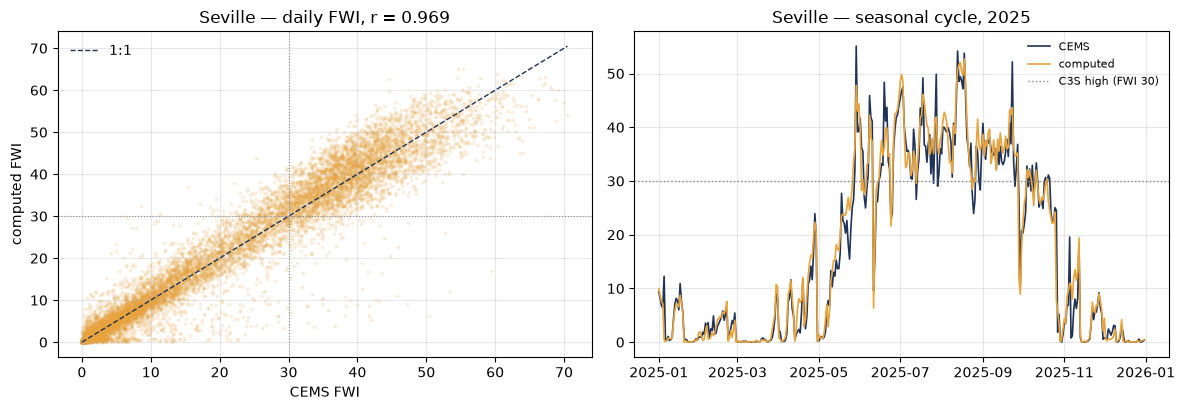

In [8]:
if overlaps:
    n = len(overlaps)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4.2 * n), squeeze=False)
    for row, (city, j) in enumerate(overlaps.items()):
        r = validation_tables[city].loc["fwi", "r"]
        ax = axes[row][0]
        ax.scatter(j["fire_weather_index"], j["fwi"], s=3, alpha=.12,
                   color=SITES[city]["colour"])
        lim = [0, max(j["fwi"].max(), j["fire_weather_index"].max())]
        ax.plot(lim, lim, color="#1F3357", lw=1, ls="--", label="1:1")
        ax.axhline(FWI_THRESHOLD, color="#888", ls=":", lw=.8)
        ax.axvline(FWI_THRESHOLD, color="#888", ls=":", lw=.8)
        ax.set_xlabel("CEMS FWI"); ax.set_ylabel("computed FWI")
        ax.set_title(f"{SITES[city]['label']} — daily FWI, r = {r:.3f}")
        ax.legend(frameon=False); ax.grid(alpha=.3)

        # last complete year in the overlap, not "max year - 5"
        counts = j.groupby(j.index.year).size()
        yr = int(counts[counts >= 360].index.max())
        s = j.loc[str(yr)]
        ax = axes[row][1]
        ax.plot(s.index, s["fire_weather_index"], lw=1.2, color="#1F3357", label="CEMS")
        ax.plot(s.index, s["fwi"], lw=1.2, color=SITES[city]["colour"], label="computed")
        ax.axhline(FWI_THRESHOLD, color="#888", ls=":", lw=1,
                   label=f"C3S high (FWI {FWI_THRESHOLD:.0f})")
        ax.set_title(f"{SITES[city]['label']} — seasonal cycle, {yr}")
        ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.3)

    plt.tight_layout(); plt.savefig(FIGS / "fwi_validation.png", dpi=150); plt.show()
else:
    print("[skip] no overlap to plot")

## 2. Annual indicators — which metrics survive validation

Daily correlation is reassuring, but the study reports annual quantities. This is where the
persistence problem shows up, and it is the reason `longest_high_run` does not appear in the
projection results.

Partial years are dropped before anything is counted. A year that runs to 30 June contributes a
day count roughly half its true value, which would drag the correlation and the bias in ways that
have nothing to do with the physics.

In [9]:
def spell_count(x, threshold=FWI_THRESHOLD, min_len=5):
    "Number of distinct stretches of >= min_len consecutive days above threshold."
    above = (x > threshold).astype(int).values
    n = run = 0
    for v in above:
        run = run + 1 if v else 0
        if run == min_len:
            n += 1
    return n


def longest_run(x, threshold=FWI_THRESHOLD):
    above = (x > threshold).astype(int).values
    best = run = 0
    for v in above:
        run = run + 1 if v else 0
        best = max(best, run)
    return best


def metric_agreement(j):
    j, dropped = complete_years(j)
    if dropped:
        print(f"  (partial years dropped: {dropped})")
    rows = []
    for yr, s in j.groupby(j.index.year):
        rows.append({
            "year": int(yr),
            "days_mine":  int((s["fwi"] > FWI_THRESHOLD).sum()),
            "days_cems":  int((s["fire_weather_index"] > FWI_THRESHOLD).sum()),
            "run_mine":   longest_run(s["fwi"]),
            "run_cems":   longest_run(s["fire_weather_index"]),
            "spell_mine": spell_count(s["fwi"]),
            "spell_cems": spell_count(s["fire_weather_index"]),
        })
    return pd.DataFrame(rows).set_index("year")


agreement, metric_verdicts = {}, {}
for city, j in overlaps.items():
    a = metric_agreement(j)
    agreement[city] = a
    print(f"\n{SITES[city]['label']}  ({len(a)} complete years)")
    for m in ["days", "run", "spell"]:
        r = a[f"{m}_mine"].corr(a[f"{m}_cems"])
        b = (a[f"{m}_mine"] - a[f"{m}_cems"]).mean()
        keep = "KEEP" if r >= 0.85 else "DROP"
        metric_verdicts[(city, m)] = dict(r=r, bias=b, keep=keep == "KEEP")
        print(f"  {m:6s} r = {r:6.3f}  bias = {b:+6.1f}   -> {keep}")
    a.to_csv(HIST_DATA / f"{city}_fwi_metric_agreement.csv")

# cross-check that longest_run here matches the module's own implementation
if agreement and hasattr(F, "annual_indicators"):
    city = next(iter(agreement))
    j = overlaps[city]
    mine = F.annual_indicators(j[["fwi"]], FWI_THRESHOLD)["longest_high_run"]
    ours = agreement[city]["run_mine"]
    common = mine.index.intersection(ours.index)
    delta = (mine.loc[common] - ours.loc[common]).abs().max()
    print(f"\nlongest_run cross-check vs F.annual_indicators: max |diff| = {delta}")


Seville  (35 complete years)
  days   r =  0.957  bias =   +3.3   -> KEEP
  run    r =  0.776  bias =  +14.3   -> DROP
  spell  r =  0.572  bias =   -0.6   -> DROP

longest_run cross-check vs F.annual_indicators: max |diff| = 0


**Why persistence fails.** Run length integrates the slow moisture codes. A small persistent
difference in drying — the drought-code bias is roughly 3% — compounds across a season into a large
difference in how long a stretch stays unbroken, while daily FWI correlation stays high. The
disagreement does not track near-threshold day counts (r ≈ 0.09 against that), so it is not simple
threshold brittleness; the sign also flips between years, which a constant offset cannot produce.

Spell counting degrades more gracefully in principle but validated no better in practice.

**Consequence:** report `days_fwi_gt30`. State the persistence finding as a limitation rather than
reporting a number that does not hold up. That is a stronger methods position than quietly
publishing the run length.

## 3. Warm start from CEMS

FWI is sequential and the drought code carries months of memory, so a cold start contaminates the
first season. Where CEMS covers the end of 2025, the projection is initialised from its codes,
removing the discontinuity at the historical/projection seam.

CEMS supplies DC, FFMC and BUI but not DMC. DMC is recovered by inverting the BUI relation, which
is piecewise: the familiar closed form is only valid where `DMC ≤ 0.4·DC`, and silently returns
nonsense above it — at DC = 200, BUI = 149 it gives 1080 against a true DMC of 150. The inversion
below solves the full function numerically and falls back to the xclim default only when no root
exists. Note the CEMS codes carry their own bias correction, so a warm start sits on a slightly
shifted scale — still better than an arbitrary cold one.

In [10]:
def warm_start_codes(city, on="2025-12-31", tolerance_days=7):
    cfg = SITES[city]
    if not have_cems.get(city):
        print(f"[{city}] no CEMS record -> cold start")
        return None, None, None

    cems = read_daily(cfg["cems"])
    target = pd.Timestamp(on)
    if target in cems.index:
        row, used = cems.loc[target], target
    else:
        # fall back to the nearest available day within tolerance
        gaps = (cems.index - target).to_series().abs()
        nearest = gaps.idxmin()
        if abs((nearest - target).days) > tolerance_days:
            print(f"[{city}] {on} not in CEMS (nearest {nearest.date()}) -> cold start")
            return None, None, None
        row, used = cems.loc[nearest], nearest
        print(f"[{city}] {on} absent, using nearest {used.date()}")

    need = ["drought_code", "fine_fuel_moisture_code", "build_up_index"]
    if any(c not in cems.columns for c in need) or row[need].isna().any():
        print(f"[{city}] CEMS codes incomplete on {used.date()} -> cold start")
        return None, None, None

    dc0 = float(row["drought_code"])
    ffmc0 = float(row["fine_fuel_moisture_code"])
    bui = float(row["build_up_index"])
    dmc0, how = invert_bui_to_dmc(bui, dc0)
    if dmc0 is None:
        print(f"[{city}] DMC inversion failed ({how}) -> xclim default for DMC")
    else:
        resid = abs(_bui(dmc0, dc0) - bui)
        print(f"[{city}] DMC {dmc0:.2f} via {how}, BUI residual {resid:.2e}")

    print(f"[{city}] warm start {used.date()}: ffmc0={ffmc0:.2f} "
          f"dmc0={'%.2f' % dmc0 if dmc0 is not None else 'default'} dc0={dc0:.2f}")
    return ffmc0, dmc0, dc0


WARM = {city: warm_start_codes(city) for city in SITES}

[seville] DMC 1.41 via analytic (branch 1), BUI residual 0.00e+00
[seville] warm start 2025-12-31: ffmc0=72.66 dmc0=1.41 dc0=222.80


## 4. Projection runs

Two things worth naming here.

**Filenames carry the model tag.** Outputs are written as
`{city}_fwi_{model}_{scenario}_{start}_{end}.csv`. The earlier convention omitted the model, which
is the same class of bug the scenario-scoping patch fixed: two runs from different models land on
the same path and the second silently overwrites the first, with nothing in the file to say which
is which. The reader in section 0 still accepts the old untagged names so existing files are not
orphaned.

**Cold start does not cost a year.** Where no warm start is available, the first year of the record
is prepended as a synthetic spin-up rather than integrating from 2026 and discarding it. The
projection window stays 2026–2045 either way, and the two paths become comparable. This is a
weaker initialisation than the CEMS warm start — it assumes the year before 2026 resembles 2026 —
but it is bounded, and the discard removes the transient.

In [11]:
projections, run_log = {}, {}

for city, cfg in SITES.items():
    src = PROJ_SRC.get(city)
    if src is None:
        print(f"[skip] {cfg['label']}: no bias-corrected projection file")
        continue

    print(f"\n=== {cfg['label']} / {SCENARIO_LABEL} / {MODEL} ===")
    ffmc0, dmc0, dc0 = WARM[city]

    full = read_daily(src)
    full, cont = ensure_daily_continuity(full, label=f"{city} proj")

    missing_cols = [c for c in [PROJ_MAP["tasmax"], PROJ_MAP["pr"], PROJ_RH, PROJ_WIND]
                    if c not in full.columns]
    if missing_cols:
        print(f"  ! missing columns {missing_cols} - skipping")
        continue

    trunc = full.loc[str(PROJ_START):str(PROJ_END)]
    if trunc.empty:
        print(f"  ! source covers {full.index.min().date()}..{full.index.max().date()}, "
              f"nothing in {PROJ_START}-{PROJ_END} - skipping")
        continue
    print(f"  source {full.index.min().date()}..{full.index.max().date()} "
          f"-> window {trunc.index.min().date()}..{trunc.index.max().date()}")
    if trunc.index.min().year > PROJ_START or trunc.index.max().year < PROJ_END:
        print(f"  ! window incomplete - reported periods will be short")

    check_inputs(trunc, PROJ_MAP["tasmax"], PROJ_RH, PROJ_WIND, PROJ_MAP["pr"],
                 wind_units="m/s", label=f"{city} proj")

    # --- spin-up strategy
    warm = ffmc0 is not None
    feed = trunc
    if not warm:
        spin = trunc.iloc[:SPINUP_DAYS].copy()
        spin.index = spin.index - pd.DateOffset(years=1)
        feed = pd.concat([spin, trunc])
        feed = feed[~feed.index.duplicated(keep="last")].sort_index()
        print(f"  cold start -> {len(spin)} synthetic spin-up days prepended "
              f"({feed.index.min().date()}), discarded after integration")

    tmp = DATA / f"_tmp_{city}_proj_feed.csv"
    try:
        feed.to_csv(tmp)
        w = F.prepare(daily_csv=str(tmp), wind_csv=None, city=city,
                      colmap={**F.DEFAULT_MAP, **PROJ_MAP},
                      rh_col=PROJ_RH, wind_col=PROJ_WIND, wind_units="m/s")
        kwargs = {k: v for k, v in dict(ffmc0=ffmc0, dmc0=dmc0, dc0=dc0).items()
                  if v is not None}          # let xclim supply its own defaults
        out = F.compute_fwi(w, lat=cfg["lat"], **kwargs)
    finally:
        tmp.unlink(missing_ok=True)

    out = out.loc[str(PROJ_START):str(PROJ_END)]

    dst = DATA / f"{city}_fwi_{MODEL_TAG}_{SCENARIO}_{PROJ_START}_{PROJ_END}.csv"
    out.to_csv(dst, float_format="%.4f")
    projections[city] = out
    run_log[city] = dict(source=str(src), warm_start=warm, ffmc0=ffmc0, dmc0=dmc0, dc0=dc0,
                         inserted_days=cont["inserted"], clim_filled=cont.get("clim_filled", 0),
                         rows=len(out))
    print(f"  -> {dst.name}  ({len(out)} rows, "
          f"{out.index.min().date()} to {out.index.max().date()})")


=== Seville / SSP2-4.5 / CMCC-ESM2 ===
  [seville proj] inserted 5 missing days (5 of them 29 Feb -> 365-day model calendar), longest gap 1 d
  source 2026-01-01..2045-12-31 -> window 2026-01-01..2045-12-31
  [seville proj] input check OK (T 2.1..44.9 C, RH 0..99 %, wind median 2.4 m/s, precip 468 mm/yr)
[prepare] humidity: column 'rh_min_percent' used directly
[prepare] wind: column 'wind_avg' x3.6 -> km/h
[prepare] 7305 days  2026-01-01 -> 2045-12-31
          tasmax  mean 24.6 degC
          hurs    mean 46.7 %
          wind    mean 9.2 km/h  (climatology)
          precip  mean 1.28 mm/day


  -> seville_fwi_cmcc_esm2_ssp245_2026_2045.csv  (7305 rows, 2026-01-01 to 2045-12-31)


In [12]:
annuals = {}
for city, df in projections.items():
    df, dropped = complete_years(df)
    if dropped:
        print(f"[{city}] partial years dropped: {dropped}")

    ann = F.annual_indicators(df, FWI_THRESHOLD)[
        ["days_fwi_gt30", "fwi_mean", "fwi_p95", "fwi_max"]]      # persistence dropped

    # all three C3S reporting thresholds, so the headline sits in context
    for name, thr in C3S_THRESHOLDS.items():
        col = f"days_fwi_gt{thr:.0f}"
        ann[col] = df.groupby(df.index.year)["fwi"].apply(lambda s, t=thr: int((s > t).sum()))
    # JJAS mean, the C3S fire-season summary statistic
    jjas = df[df.index.month.isin([6, 7, 8, 9])]
    ann["fwi_jjas_mean"] = jjas.groupby(jjas.index.year)["fwi"].mean().round(3)

    ann = ann[["days_fwi_gt15", "days_fwi_gt30", "days_fwi_gt45",
               "fwi_mean", "fwi_jjas_mean", "fwi_p95", "fwi_max"]]
    ann.to_csv(DATA / f"{city}_fwi_{MODEL_TAG}_{SCENARIO}_{PROJ_START}_{PROJ_END}_annual.csv")
    annuals[city] = ann
    print(f"{SITES[city]['label']}: {len(ann)} years -> "
          f"{city}_fwi_{MODEL_TAG}_{SCENARIO}_{PROJ_START}_{PROJ_END}_annual.csv")

    # consistency: days_fwi_gt30 from the module vs computed here
    chk = df.groupby(df.index.year)["fwi"].apply(lambda s: int((s > FWI_THRESHOLD).sum()))
    assert (ann["days_fwi_gt30"] == chk.loc[ann.index]).all(), \
        "days_fwi_gt30 disagrees with F.annual_indicators - check the threshold convention"

if annuals:
    display(pd.concat({SITES[c]["label"]: a for c, a in annuals.items()},
                      axis=1).head(8).round(2))
else:
    print("no projections to summarise")

Seville: 20 years -> seville_fwi_cmcc_esm2_ssp245_2026_2045_annual.csv


Seville                                                             \
     days_fwi_gt15 days_fwi_gt30 days_fwi_gt45 fwi_mean fwi_jjas_mean fwi_p95   
year                                                                            
2026           198           108            27    20.41         36.83   47.40   
2027           156           114            34    18.01         33.88   50.64   
2028           237           152            45    24.01         39.74   50.58   
2029           245           155            79    26.75         44.36   53.78   
2030           296           213            69    30.86         42.58   54.61   
2031           199           138            62    21.84         42.10   51.45   
2032           225           135            58    22.98         42.28   50.96   
2033           196           125            62    23.01         40.57   52.41   

              
     fwi_max  
year          
2026   58.96  
2027   61.68  
2028   62.44  
2029   68.21  
2030   62.32  
2031   64.43  
2032   58.94  
2033   62.63

## 4.1 Raw (uncorrected) projection run, for a plot-consistent comparison

Every other indicator in this project (temperature, precipitation, SPI-3) gets shown raw-vs-corrected
side by side. FWI hasn't, because section 4 only ever ran on the bias-corrected file. This section
adds the missing raw run, reusing the exact same FWI machinery (`F.prepare`/`F.compute_fwi`, the same
warm-start codes from section 3, the same cold-start spin-up, the same lat/thresholds) -- the only
thing that changes is the driving daily series: `cmip6_grid_processing.grid_average_daily()` applied
directly to the untouched CMIP6 pull (`data/{city}_cmip6_{scenario}_2026_2045.csv`), instead of the
Equidistant-CDF-Matching-corrected file section 4 uses. That function already derives
`rh_min_percent` the same way the corrected pipeline does (added upstream specifically for this FWI
use case), so the column names line up with `PROJ_MAP`/`PROJ_RH`/`PROJ_WIND` without any translation
layer.

**What this validates and what it doesn't.** Section 1's r=0.969 validation is of the FWI
*computation* itself (the xclim formula, correctly wired) -- that doesn't change here, only the input
weather series does. What's untested is whether *raw, biased* CMIP6 weather plugged into that same
formula gives a sensible fire-danger number -- which is exactly the point of running it: the gap
between this and section 4's corrected run *is* the bias correction's effect on projected fire risk,
not a second, independently unvalidated fire model.


In [13]:
from cmip6_grid_processing import grid_average_daily

RAW_CMIP6 = {city: DATA / f"{city}_cmip6_{SCENARIO}_{PROJ_START}_{PROJ_END}.csv" for city in SITES}

projections_raw, run_log_raw = {}, {}

for city, cfg in SITES.items():
    src = RAW_CMIP6.get(city)
    if src is None or not Path(src).exists():
        print(f"[skip] {cfg['label']}: no raw CMIP6 pull at {src}")
        continue

    print(f"\n=== {cfg['label']} / {SCENARIO_LABEL} / {MODEL} -- RAW (uncorrected) ===")
    ffmc0, dmc0, dc0 = WARM[city]

    full = grid_average_daily(src)          # tmax_c, precip_mm_day, wind_avg, rh_min_percent, ...
    full, cont = ensure_daily_continuity(full, label=f"{city} raw proj")

    missing_cols = [c for c in [PROJ_MAP["tasmax"], PROJ_MAP["pr"], PROJ_RH, PROJ_WIND]
                    if c not in full.columns]
    if missing_cols:
        print(f"  ! missing columns {missing_cols} - skipping")
        continue

    trunc = full.loc[str(PROJ_START):str(PROJ_END)]
    if trunc.empty:
        print(f"  ! source covers {full.index.min().date()}..{full.index.max().date()}, "
              f"nothing in {PROJ_START}-{PROJ_END} - skipping")
        continue
    print(f"  source {full.index.min().date()}..{full.index.max().date()} "
          f"-> window {trunc.index.min().date()}..{trunc.index.max().date()}")

    check_inputs(trunc, PROJ_MAP["tasmax"], PROJ_RH, PROJ_WIND, PROJ_MAP["pr"],
                 wind_units="m/s", label=f"{city} raw proj")

    # same spin-up strategy as section 4 -- identical warm/cold-start logic
    warm = ffmc0 is not None
    feed = trunc
    if not warm:
        spin = trunc.iloc[:SPINUP_DAYS].copy()
        spin.index = spin.index - pd.DateOffset(years=1)
        feed = pd.concat([spin, trunc])
        feed = feed[~feed.index.duplicated(keep="last")].sort_index()
        print(f"  cold start -> {len(spin)} synthetic spin-up days prepended "
              f"({feed.index.min().date()}), discarded after integration")

    tmp = DATA / f"_tmp_{city}_proj_raw_feed.csv"
    try:
        feed.to_csv(tmp)
        w = F.prepare(daily_csv=str(tmp), wind_csv=None, city=city,
                      colmap={**F.DEFAULT_MAP, **PROJ_MAP},
                      rh_col=PROJ_RH, wind_col=PROJ_WIND, wind_units="m/s")
        kwargs = {k: v for k, v in dict(ffmc0=ffmc0, dmc0=dmc0, dc0=dc0).items()
                  if v is not None}
        out = F.compute_fwi(w, lat=cfg["lat"], **kwargs)
    finally:
        tmp.unlink(missing_ok=True)

    out = out.loc[str(PROJ_START):str(PROJ_END)]

    dst = DATA / f"{city}_fwi_{MODEL_TAG}_{SCENARIO}_{PROJ_START}_{PROJ_END}_raw.csv"
    out.to_csv(dst, float_format="%.4f")
    projections_raw[city] = out
    run_log_raw[city] = dict(source=str(src), warm_start=warm, ffmc0=ffmc0, dmc0=dmc0, dc0=dc0,
                             inserted_days=cont["inserted"], clim_filled=cont.get("clim_filled", 0),
                             rows=len(out))
    print(f"  -> {dst.name}  ({len(out)} rows, "
          f"{out.index.min().date()} to {out.index.max().date()})")



=== Seville / SSP2-4.5 / CMCC-ESM2 -- RAW (uncorrected) ===
  [seville raw proj] inserted 5 missing days (5 of them 29 Feb -> 365-day model calendar), longest gap 1 d
  source 2026-01-01..2045-12-31 -> window 2026-01-01..2045-12-31
  [seville raw proj] input check OK (T 6.1..44.8 C, RH 8..93 %, wind median 2.5 m/s, precip 266 mm/yr)
[prepare] humidity: column 'rh_min_percent' used directly
[prepare] wind: column 'wind_avg' x3.6 -> km/h
[prepare] 7305 days  2026-01-01 -> 2045-12-31
          tasmax  mean 25.5 degC
          hurs    mean 40.1 %
          wind    mean 9.3 km/h  (climatology)
          precip  mean 0.73 mm/day


  -> seville_fwi_cmcc_esm2_ssp245_2026_2045_raw.csv  (7305 rows, 2026-01-01 to 2045-12-31)


In [14]:
annuals_raw = {}
for city, df in projections_raw.items():
    df, dropped = complete_years(df)
    if dropped:
        print(f"[{city}] partial years dropped: {dropped}")

    ann = F.annual_indicators(df, FWI_THRESHOLD)[["days_fwi_gt30", "fwi_mean", "fwi_p95", "fwi_max"]]
    for name, thr in C3S_THRESHOLDS.items():
        col = f"days_fwi_gt{thr:.0f}"
        ann[col] = df.groupby(df.index.year)["fwi"].apply(lambda s, t=thr: int((s > t).sum()))
    jjas = df[df.index.month.isin([6, 7, 8, 9])]
    ann["fwi_jjas_mean"] = jjas.groupby(jjas.index.year)["fwi"].mean().round(3)
    ann = ann[["days_fwi_gt15", "days_fwi_gt30", "days_fwi_gt45",
               "fwi_mean", "fwi_jjas_mean", "fwi_p95", "fwi_max"]]

    dst = DATA / f"{city}_fwi_{MODEL_TAG}_{SCENARIO}_{PROJ_START}_{PROJ_END}_raw_annual.csv"
    ann.to_csv(dst)
    annuals_raw[city] = ann
    print(f"{SITES[city]['label']}: {len(ann)} years -> {dst.name}")

if annuals_raw:
    display(pd.concat({SITES[c]["label"]: a for c, a in annuals_raw.items()}, axis=1).head(8).round(2))


Seville: 20 years -> seville_fwi_cmcc_esm2_ssp245_2026_2045_raw_annual.csv


Seville                                                             \
     days_fwi_gt15 days_fwi_gt30 days_fwi_gt45 fwi_mean fwi_jjas_mean fwi_p95   
year                                                                            
2026           225           150            69    25.78         43.45   56.87   
2027           193           126            84    23.59         41.80   60.65   
2028           261           191           100    31.07         49.32   60.69   
2029           307           195           126    34.73         53.96   63.49   
2030           325           241           124    37.12         52.23   62.98   
2031           228           161           109    27.82         50.47   61.07   
2032           254           168           100    28.89         50.28   60.92   
2033           257           158           105    30.09         46.80   62.28   

              
     fwi_max  
year          
2026   66.60  
2027   68.50  
2028   70.48  
2029   75.89  
2030   73.73  
2031   71.97  
2032   69.95  
2033   69.98

### 4.1.1 Raw vs. bias-corrected, `days_fwi_gt30`

Same before/after framing used throughout this project for every other bias-corrected indicator.


,raw_mean_days,corrected_mean_days,delta_days,delta_pct
city,,,,
Seville,170.6,140.2,-30.4,-17.8


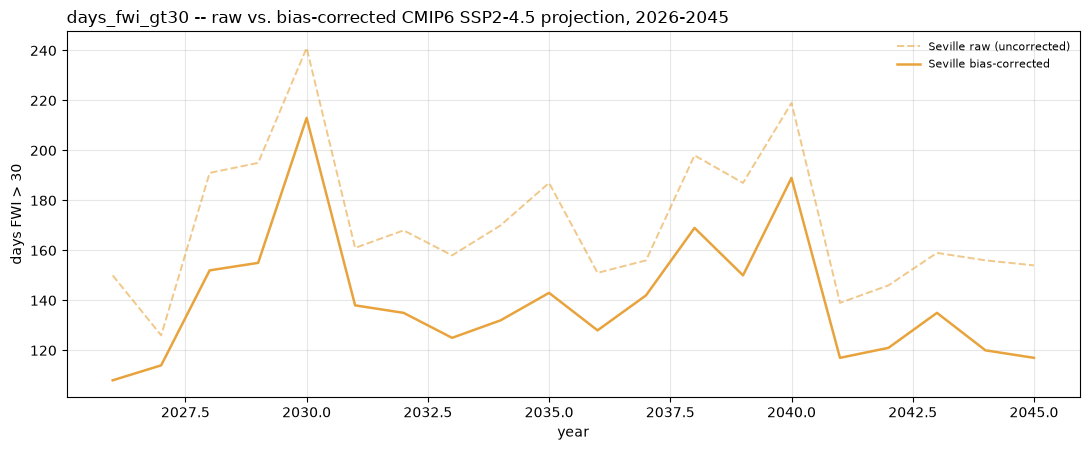

In [15]:
rows = []
for city in SITES:
    if city not in annuals or city not in annuals_raw:
        continue
    raw_mean = annuals_raw[city]["days_fwi_gt30"].mean()
    corr_mean = annuals[city]["days_fwi_gt30"].mean()
    rows.append({"city": SITES[city]["label"], "raw_mean_days": round(raw_mean, 1),
                 "corrected_mean_days": round(corr_mean, 1),
                 "delta_days": round(corr_mean - raw_mean, 1),
                 "delta_pct": round(100 * (corr_mean - raw_mean) / raw_mean, 1) if raw_mean else np.nan})
raw_vs_corrected = pd.DataFrame(rows).set_index("city")
raw_vs_corrected.to_csv(DATA / f"fwi_raw_vs_corrected_{MODEL_TAG}_{SCENARIO}.csv")
display(raw_vs_corrected)

fig, ax = plt.subplots(figsize=(11, 4.6))
for city in SITES:
    if city not in annuals or city not in annuals_raw:
        continue
    cfg = SITES[city]
    ax.plot(annuals_raw[city].index, annuals_raw[city]["days_fwi_gt30"], "--", lw=1.4,
            color=cfg["colour"], alpha=0.6, label=f"{cfg['label']} raw (uncorrected)")
    ax.plot(annuals[city].index, annuals[city]["days_fwi_gt30"], "-", lw=1.8,
            color=cfg["colour"], label=f"{cfg['label']} bias-corrected")
ax.set_xlabel("year"); ax.set_ylabel(f"days FWI > {FWI_THRESHOLD:.0f}")
ax.set_title("days_fwi_gt30 -- raw vs. bias-corrected CMIP6 SSP2-4.5 projection, 2026-2045", loc="left")
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIGS / "fwi_raw_vs_corrected.png", dpi=150); plt.show()


### 4.1.2 Finding

**Bias correction reduces projected fire risk for Seville under SSP2-4.5 too -- consistent in
direction and rough magnitude with the SSP5-8.5 notebook's own finding for this city:**

| Scenario | Raw mean (2026-2045) | Corrected mean | Change |
|---|---|---|---|
| SSP2-4.5 (this run) | 170.6 days/yr | 140.2 days/yr | **-30.4 days (-17.8%)** |
| SSP5-8.5 (for comparison) | 176.6 days/yr | 147.8 days/yr | -28.8 days (-16.3%) |

Same underlying cause as SSP5-8.5's own finding: `cmcc_esm2`'s raw output for Seville runs both too
hot and too dry regardless of which SSP experiment drives it (both are the same historical-run bias
relative to ERA5, from the same model), so correcting both pulls the fire-danger day count down by a
similar relative amount under either scenario. That the two independently-run scenarios land on such
close raw-vs-corrected percentages (-17.8% vs. -16.3%) is a reasonable consistency check on the
correction methodology itself, not a coincidence -- it's the same model bias showing up the same way
regardless of which future forcing is layered on top of it.

**Practical takeaway, same as SSP5-8.5's:** the raw series is not just a noisier version of the
corrected one -- it's substantially more alarming for both scenarios, which matters if raw and
corrected are ever shown or quoted without the bias-correction context attached.

## 5. Baseline and change

The baseline must come from **this pipeline**, not from CEMS. Mixing a CEMS-derived historical
figure with an xclim-derived projection would inject the validation offset straight into the
headline change number. Both ends use `{city}_fwi_era5_validation.csv`, computed in section 1.

The change table carries a `distinguishable` flag: where the projected change is smaller than the
interannual standard deviation of the projection itself, the difference is inside the noise of a
single model run and should be described as such rather than quoted as a projection.

In [16]:
baselines = {}
for city, v in validations.items():
    sub = v.loc[str(BASE_START):str(BASE_END)]
    sub, dropped = complete_years(sub)
    if sub.empty:
        print(f"[{SITES[city]['label']}] no complete years in {BASE_START}-{BASE_END}")
        continue
    b = F.annual_indicators(sub, FWI_THRESHOLD)
    for name, thr in C3S_THRESHOLDS.items():
        b[f"days_fwi_gt{thr:.0f}"] = sub.groupby(sub.index.year)["fwi"].apply(
            lambda s, t=thr: int((s > t).sum()))
    jjas = sub[sub.index.month.isin([6, 7, 8, 9])]
    b["fwi_jjas_mean"] = jjas.groupby(jjas.index.year)["fwi"].mean()
    baselines[city] = b
    print(f"{SITES[city]['label']} baseline {b.index.min()}-{b.index.max()} "
          f"({len(b)} yrs): days_fwi_gt30 = {b['days_fwi_gt30'].mean():.1f} "
          f"+/- {b['days_fwi_gt30'].std():.1f}")
    if len(b) < (BASE_END - BASE_START + 1):
        print(f"  ! only {len(b)} of {BASE_END - BASE_START + 1} baseline years available")

Seville baseline 1991-2020 (30 yrs): days_fwi_gt30 = 126.2 +/- 24.2


In [17]:
METRICS = ["days_fwi_gt15", "days_fwi_gt30", "days_fwi_gt45", "fwi_jjas_mean"]

rows = []
for city, ann in annuals.items():
    base = baselines.get(city)
    if base is None:
        print(f"[{SITES[city]['label']}] no baseline - change not computed")
        continue
    for metric in METRICS:
        if metric not in base.columns or metric not in ann.columns:
            continue
        b0 = float(base[metric].mean())
        for label, (y0, y1) in PERIODS.items():
            sub = ann.loc[(ann.index >= y0) & (ann.index <= y1), metric]
            if sub.empty:
                continue
            change = float(sub.mean()) - b0
            sd = float(sub.std())
            rows.append({
                "city": SITES[city]["label"],
                "metric": metric,
                "period": label,
                "baseline": round(b0, 1),
                "projected": round(float(sub.mean()), 1),
                "change": round(change, 1),
                "change_pct": round(100 * change / b0, 1) if b0 > 0 else np.nan,
                "interannual_sd": round(sd, 1),
                "distinguishable": bool(abs(change) > sd),
            })

change_table = pd.DataFrame(rows)
if not change_table.empty:
    change_table.to_csv(DATA / f"fwi_change_{MODEL_TAG}_{SCENARIO}.csv", index=False)
    display(change_table[change_table["metric"] == "days_fwi_gt30"])
    print("\nAll metrics:")
    display(change_table)
    weak = change_table[~change_table["distinguishable"]]
    if len(weak):
        print(f"\n{len(weak)} row(s) where |change| < interannual SD - describe as "
              f"'within the variability of a single run', not as a projected change:")
        display(weak[["city", "metric", "period", "change", "interannual_sd"]])
else:
    print("change table empty - needs both a baseline (section 1) and a projection (section 4)")

,city,metric,period,baseline,projected,change,change_pct,interannual_sd,distinguishable
3,Seville,days_fwi_gt30,2026-2035,126.2,141.5,15.3,12.2,29.3,False
4,Seville,days_fwi_gt30,2036-2045,126.2,138.8,12.6,10.0,24.3,False
5,Seville,days_fwi_gt30,2026-2045,126.2,140.2,14.0,11.1,26.2,False



All metrics:


,city,metric,period,baseline,projected,change,change_pct,interannual_sd,distinguishable
0,Seville,days_fwi_gt15,2026-2035,184.0,216.1,32.1,17.4,37.8,False
1,Seville,days_fwi_gt15,2036-2045,184.0,203.3,19.3,10.5,34.6,False
2,Seville,days_fwi_gt15,2026-2045,184.0,209.7,25.7,14.0,35.9,False
3,Seville,days_fwi_gt30,2026-2035,126.2,141.5,15.3,12.2,29.3,False
4,Seville,days_fwi_gt30,2036-2045,126.2,138.8,12.6,10.0,24.3,False
5,Seville,days_fwi_gt30,2026-2045,126.2,140.2,14.0,11.1,26.2,False
6,Seville,days_fwi_gt45,2026-2035,42.1,59.1,17.0,40.4,18.4,False
7,Seville,days_fwi_gt45,2036-2045,42.1,51.6,9.5,22.6,19.8,False
8,Seville,days_fwi_gt45,2026-2045,42.1,55.4,13.2,31.5,19.0,False
9,Seville,fwi_jjas_mean,2026-2035,38.8,41.0,2.2,5.7,3.4,False



12 row(s) where |change| < interannual SD - describe as 'within the variability of a single run', not as a projected change:


,city,metric,period,change,interannual_sd
0,Seville,days_fwi_gt15,2026-2035,32.1,37.8
1,Seville,days_fwi_gt15,2036-2045,19.3,34.6
2,Seville,days_fwi_gt15,2026-2045,25.7,35.9
3,Seville,days_fwi_gt30,2026-2035,15.3,29.3
4,Seville,days_fwi_gt30,2036-2045,12.6,24.3
5,Seville,days_fwi_gt30,2026-2045,14.0,26.2
6,Seville,days_fwi_gt45,2026-2035,17.0,18.4
7,Seville,days_fwi_gt45,2036-2045,9.5,19.8
8,Seville,days_fwi_gt45,2026-2045,13.2,19.0
9,Seville,fwi_jjas_mean,2026-2035,2.2,3.4


In [18]:
rows = []
for city, ann in annuals.items():
    for metric in ["days_fwi_gt30", "fwi_mean", "fwi_jjas_mean", "fwi_p95"]:
        if metric not in ann.columns:
            continue
        t = theil_sen(ann[metric])
        rows.append({"city": SITES[city]["label"], "metric": metric, "n_years": t["n"],
                     "slope_per_decade": round(t["slope"] * 10, 3),
                     "ci95_lo_per_decade": round(t["lo"] * 10, 3),
                     "ci95_hi_per_decade": round(t["hi"] * 10, 3),
                     "kendall_tau": round(t["tau"], 3),
                     "p_value": round(t["p"], 4),
                     "sig_05": bool(t["p"] < 0.05) if np.isfinite(t["p"]) else False})

trend_table = pd.DataFrame(rows)
if not trend_table.empty:
    trend_table.to_csv(DATA / f"fwi_trends_{MODEL_TAG}_{SCENARIO}.csv", index=False)
    display(trend_table)
else:
    print("no annual series to fit trends to")

,city,metric,n_years,slope_per_decade,ci95_lo_per_decade,ci95_hi_per_decade,kendall_tau,p_value,sig_05
0,Seville,days_fwi_gt30,20,-8.333,-21.000,15.882,-0.095,0.5588,False
1,Seville,fwi_mean,20,-0.824,-3.318,3.014,-0.053,0.7732,False
2,Seville,fwi_jjas_mean,20,0.345,-3.175,3.598,0.074,0.6771,False
3,Seville,fwi_p95,20,0.295,-3.105,2.483,0.021,0.9235,False


Over a 20-year window the sample is small and p-values will often sit above 0.05 even where the
direction is consistent, so report direction and magnitude first — the 95% confidence interval on
the slope is more informative here than the p-value. This mirrors the baseline-model finding from
earlier in the project: the trend is detectable while a naive baseline still wins on forecast
skill, and neither result invalidates the other.

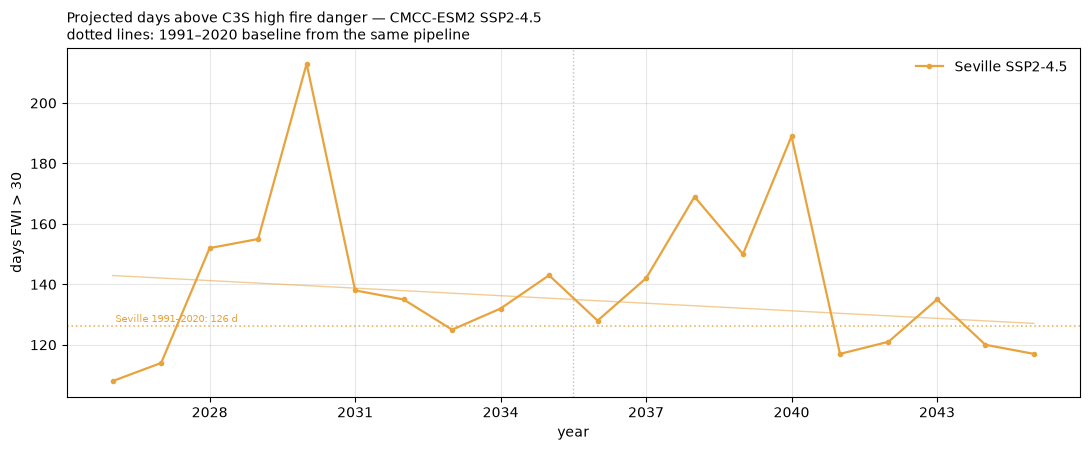

In [19]:
if annuals:
    fig, ax = plt.subplots(figsize=(11, 4.6))
    for city, ann in annuals.items():
        cfg = SITES[city]
        y = ann["days_fwi_gt30"]
        ax.plot(ann.index, y, lw=1.6, marker="o", ms=3,
                color=cfg["colour"], label=f"{cfg['label']} {SCENARIO_LABEL}")
        t = theil_sen(y)
        if np.isfinite(t["slope"]):
            x = np.asarray(ann.index, dtype=float)
            # Theil-Sen intercept, not an anchor on the first year's value
            ax.plot(ann.index, t["slope"] * x + t["intercept"],
                    color=cfg["colour"], lw=1, alpha=.55)
        if city in baselines:
            b0 = baselines[city]["days_fwi_gt30"].mean()
            ax.axhline(b0, color=cfg["colour"], ls=":", lw=1.2, alpha=.8)
            ax.annotate(f"{cfg['label']} {BASE_START}–{BASE_END}: {b0:.0f} d",
                        xy=(ann.index.min(), b0), xytext=(2, 3),
                        textcoords="offset points", fontsize=7.5, color=cfg["colour"])

    ax.axvline(2035.5, color="#999", lw=1, ls=":", alpha=.6)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))   # years, not 2027.5
    ax.set_xlabel("year"); ax.set_ylabel(f"days FWI > {FWI_THRESHOLD:.0f}")
    ax.set_title(f"Projected days above C3S high fire danger — {MODEL} {SCENARIO_LABEL}\n"
                 f"dotted lines: {BASE_START}–{BASE_END} baseline from the same pipeline",
                 loc="left", fontsize=10)
    ax.legend(frameon=False); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(FIGS / "fwi_projection_days.png", dpi=150); plt.show()
else:
    print("[skip] nothing to plot")

### 5.1 Where in the year the change lands

A day count says how much fire weather there is; it says nothing about *when*. For adaptation and
emergency planning the shoulder months matter — a season that starts three weeks earlier is a
different staffing problem from one that simply gets hotter in August. The monthly climatology
below is built from daily FWI, which is the quantity that validated, so it inherits the daily
validation rather than the persistence problem.

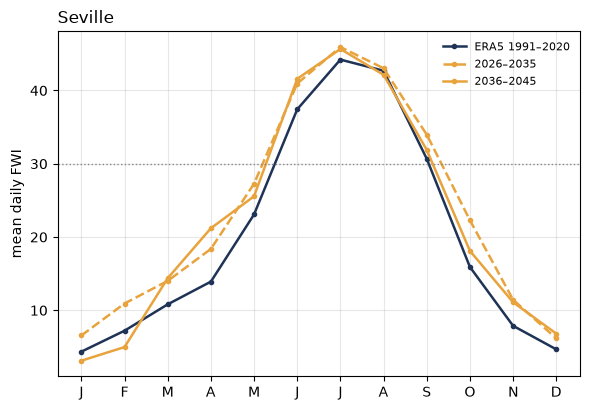

No month crosses the FWI 30 mean threshold that did not already.


In [20]:
def monthly_clim(daily, col="fwi"):
    return daily.groupby(daily.index.month)[col].mean()


if projections and validations:
    fig, axes = plt.subplots(1, len(projections), figsize=(6 * len(projections), 4.2),
                             squeeze=False)
    months = np.arange(1, 13)
    season_rows = []
    for i, (city, proj) in enumerate(projections.items()):
        ax = axes[0][i]
        cfg = SITES[city]
        if city in validations:
            base = validations[city].loc[str(BASE_START):str(BASE_END)]
            ax.plot(months, monthly_clim(base).reindex(months), lw=1.8, color="#1F3357",
                    marker="o", ms=3, label=f"ERA5 {BASE_START}–{BASE_END}")
        for (lo, hi), style in [((2026, 2035), "--"), ((2036, 2045), "-")]:
            sub = proj.loc[str(lo):str(hi)]
            if sub.empty:
                continue
            ax.plot(months, monthly_clim(sub).reindex(months), lw=1.8, ls=style,
                    color=cfg["colour"], marker="o", ms=3, label=f"{lo}–{hi}")
        ax.axhline(FWI_THRESHOLD, color="#888", ls=":", lw=1)
        ax.set_xticks(months)
        ax.set_xticklabels(list("JFMAMJJASOND"))
        ax.set_ylabel("mean daily FWI"); ax.set_title(cfg["label"], loc="left")
        ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.3)

        # months newly crossing the threshold in the mean
        if city in validations:
            b = monthly_clim(validations[city].loc[str(BASE_START):str(BASE_END)])
            f = monthly_clim(proj.loc["2036":"2045"])
            for m in months:
                if m in b.index and m in f.index:
                    season_rows.append({"city": cfg["label"], "month": m,
                                        "baseline": round(float(b[m]), 1),
                                        "2036_2045": round(float(f[m]), 1),
                                        "delta": round(float(f[m] - b[m]), 1),
                                        "crosses_30": bool(b[m] <= FWI_THRESHOLD < f[m])})
    plt.tight_layout(); plt.savefig(FIGS / "fwi_monthly_shift.png", dpi=150); plt.show()

    if season_rows:
        season = pd.DataFrame(season_rows)
        season.to_csv(DATA / f"fwi_monthly_shift_{MODEL_TAG}_{SCENARIO}.csv", index=False)
        crossing = season[season["crosses_30"]]
        if len(crossing):
            print("Months whose mean FWI newly exceeds 30 by 2036–2045:")
            display(crossing)
        else:
            print("No month crosses the FWI 30 mean threshold that did not already.")
else:
    print("[skip] needs both a baseline and a projection")

## 6. Caveats for the slide

The cell below fills the bracketed values from the run instead of leaving them to be transcribed
by hand — copying a correlation off a screen into a slide is exactly where the wrong number gets
into a deck.

In [21]:
lines = []
for city in SITES:
    t = validation_tables.get(city)
    if t is None:
        lines.append(f"{SITES[city]['label']}: NOT VALIDATED - no CEMS overlap available")
        continue
    j = overlaps[city]
    lines.append(
        f"{SITES[city]['label']}: FWI validated against CEMS "
        f"{j.index.min().year}-{j.index.max().year} ({len(j):,} days): "
        f"daily FWI r = {t.loc['fwi', 'r']:.3f}, drought code r = {t.loc['dc', 'r']:.3f}, "
        f"mean offset {t.loc['fwi', 'bias']:+.2f} FWI units.")

for city, a in agreement.items():
    r_run = a["run_mine"].corr(a["run_cems"])
    b_run = (a["run_mine"] - a["run_cems"]).mean()
    r_sp = a["spell_mine"].corr(a["spell_cems"])
    lines.append(f"{SITES[city]['label']}: persistence NOT reported - longest run r = {r_run:.2f} "
                 f"(bias {b_run:+.0f} d), 5-day spell count r = {r_sp:.2f}.")

for city, log in run_log.items():
    init = "warm start from CEMS 2025-12-31" if log["warm_start"] else \
           f"cold start with a {SPINUP_DAYS}-day synthetic spin-up"
    lines.append(f"{SITES[city]['label']}: projection initialised by {init}; "
                 f"{log['inserted_days']} calendar days interpolated"
                 + (f", {log['clim_filled']} filled from climatology." if log['clim_filled'] else "."))

if not change_table.empty:
    head = change_table[(change_table["metric"] == "days_fwi_gt30") &
                        (change_table["period"] == "2036-2045")]
    for _, r in head.iterrows():
        qual = "" if r["distinguishable"] else "  [within interannual variability]"
        lines.append(f"{r['city']}: days FWI>30 {r['baseline']:.0f} ({BASE_START}-{BASE_END}) "
                     f"-> {r['projected']:.0f} (2036-2045), {r['change']:+.0f} d "
                     f"({r['change_pct']:+.0f}%), SD {r['interannual_sd']:.0f}{qual}")

print("\n".join(f"- {l}" for l in lines))
(DATA / "fwi_slide_numbers.txt").write_text("\n".join(lines), encoding="utf-8")
print(f"\n-> {(DATA / 'fwi_slide_numbers.txt')}")

- Seville: FWI validated against CEMS 1991-2025 (12,784 days): daily FWI r = 0.969, drought code r = 0.987, mean offset +0.36 FWI units.
- Seville: persistence NOT reported - longest run r = 0.78 (bias +14 d), 5-day spell count r = 0.57.
- Seville: projection initialised by warm start from CEMS 2025-12-31; 5 calendar days interpolated.
- Seville: days FWI>30 126 (1991-2020) -> 139 (2036-2045), +13 d (+10%), SD 24  [within interannual variability]

-> /Users/karina/neuefische_course/week-14/capstone_project/SECS_capstone_project/Projected_SSP2-4.5/data/fwi_slide_numbers.txt


1. **Model and correction.** CMCC-ESM2, SSP2-4.5, four grid cells averaged, bias-corrected against
   ERA5 by Equidistant CDF Matching fit per city, per variable, per calendar month over the
   1990-2014 historical overlap. The method preserves the model's own projected shift rather than
   collapsing it toward historical climatology.

2. **All four FWI drivers are projected.** Including wind -- CMCC-ESM2 publishes daily `sfcWind`, so
   nothing is held at climatology.

3. **Humidity is the daily minimum.** `rh_min_percent`, derived at daily maximum temperature and
   bias-corrected as its own variable.

4. **Threshold provenance.** FWI > 30 is the C3S reporting threshold for *high* fire danger, taken
   as the mid-point of the EFFIS high class (21.3-38.0). The companion thresholds, 15 and 45, are
   reported alongside it in section 4.

5. **Validated, not calibrated.** Numbers printed in the cell above. Change figures use a baseline
   from this same pipeline, so the validation offset cancels.

6. **Persistence not projected.** Longest high-danger run and 5-day spell count did not reproduce
   against CEMS (Section 2). Reported for the historical record only, sourced from CEMS.

7. **One model, one scenario.** No structural or ensemble spread. Directional risk, not calibrated
   magnitude. Where `distinguishable` is False in the change table, the projected change sits
   inside the interannual variability of this single run and should be stated that way.

8. **Seville only.** Larissa is excluded from this notebook entirely -- it has no CEMS record to
   validate the FWI implementation against, and its fire-danger numbers are not used as a validated
   climate indicator elsewhere in this project (`larissa_cmip6_projection_eda.ipynb` Section 17).
   The SSP5-8.5 FWI notebook computes an explicitly-unvalidated Larissa run anyway, for transparency;
   this notebook doesn't reproduce that choice, since the numbers wouldn't be used regardless.

9. **Near-term horizon.** 2026-2045 sits before SSP pathways separate meaningfully -- this makes a
   single scenario a defensible choice at either scenario's near-term horizon, and this notebook now
   provides the SSP2-4.5 side of that comparison against the existing SSP5-8.5 run.

---

### Follow-ups

- [ ] Compare this run's `days_fwi_gt30` change against the SSP5-8.5 FWI notebook's own Seville
      result directly -- both now exist, using the same model, same validation, same baseline
      period, differing only in which SSP drove the projection window.
- [ ] If Larissa ever gets a CEMS-equivalent validation source, revisit whether an SSP2-4.5 Larissa
      run is worth adding, following the SSP5-8.5 notebook's own explicitly-unvalidated-but-shown
      approach rather than this notebook's Seville-only scope.

In [22]:
run_manifest = {
    "root": str(ROOT),
    "model": MODEL, "model_tag": MODEL_TAG, "scenario": SCENARIO,
    "window": [PROJ_START, PROJ_END], "baseline": [BASE_START, BASE_END],
    "threshold": FWI_THRESHOLD, "threshold_source": "C3S high (mid-point of EFFIS 21.3-38.0)",
    "xclim": xclim.__version__, "pandas": pd.__version__, "numpy": np.__version__,
    "cities_validated": sorted(validation_tables),
    "cities_projected": sorted(projections),
    "runs": run_log,
}
path = DATA / f"fwi_run_manifest_{MODEL_TAG}_{SCENARIO}.json"
path.write_text(json.dumps(run_manifest, indent=2, default=str), encoding="utf-8")
print(json.dumps(run_manifest, indent=2, default=str))
print(f"\n-> {path}")

{
  "root": "/Users/karina/neuefische_course/week-14/capstone_project/SECS_capstone_project",
  "model": "CMCC-ESM2",
  "model_tag": "cmcc_esm2",
  "scenario": "ssp245",
  "window": [
    2026,
    2045
  ],
  "baseline": [
    1991,
    2020
  ],
  "threshold": 30.0,
  "threshold_source": "C3S high (mid-point of EFFIS 21.3-38.0)",
  "xclim": "0.61.1",
  "pandas": "3.0.5",
  "numpy": "2.4.6",
  "cities_validated": [
    "seville"
  ],
  "cities_projected": [
    "seville"
  ],
  "runs": {
    "seville": {
      "source": "/Users/karina/neuefische_course/week-14/capstone_project/SECS_capstone_project/Projected_SSP2-4.5/data/seville_cmip6_cmcc_esm2_ssp245_2026_2045_biascorrected.csv",
      "warm_start": true,
      "ffmc0": 72.6553,
      "dmc0": 1.4142421278451107,
      "dc0": 222.7985,
      "inserted_days": 5,
      "clim_filled": 0,
      "rows": 7305
    }
  }
}

-> /Users/karina/neuefische_course/week-14/capstone_project/SECS_capstone_project/Projected_SSP2-4.5/data/fwi_run_manif

## Summary -- key findings (SSP2-4.5, Seville only)

**Method:** FWI computed directly from CMCC-ESM2 (SSP2-4.5), bias-corrected against ERA5 via the same
Equidistant CDF Matching pipeline used throughout this project. Same model as the SSP5-8.5 FWI
notebook, deliberately, so the two scenario runs are comparable and share the same validated
implementation.

**Validation -- Seville, identical to the SSP5-8.5 notebook's own numbers, as expected (this step
depends only on ERA5 and CEMS, not on any projection scenario):**
- Daily FWI vs. CEMS (1991-2025, 12,784 days): **r = 0.969**, drought code r = 0.987, mean offset
  +0.36 FWI units -- strong pass.
- Persistence metrics (longest high-danger run, 5-day spell count) don't reproduce well (r=0.78 with
  a +14 day bias; r=0.57) and are not reported for the projection -- only `days_fwi_gt30` is trusted
  enough to project forward.
- Larissa is excluded entirely from this notebook (see the intro) -- it has no CEMS record to
  validate against, and its FWI is not used as a climate indicator elsewhere in this project.

**Headline result -- days per year with FWI > 30 (baseline 1991-2020 -> projected 2036-2045):**

| Scenario | Baseline | Projected | Change |
|---|---|---|---|
| SSP2-4.5 (this run) | 126 days | 139 days | **+13 days (+10%)**, SD 24 -- within interannual variability |
| SSP5-8.5 (for comparison) | 126 days | 148 days | +22 days (+18%), SD 26 -- also within interannual variability |

Both scenarios' Seville change sits inside the interannual variability of a single model run -- neither
is a statistically confirmed shift on its own. SSP2-4.5's projected increase is smaller than SSP5-8.5's
in both absolute and relative terms, consistent with SSP2-4.5 being the lower-forcing pathway, though
neither difference should be read as confirmed given both sit inside the noise band.

**Other thresholds (2026-2045 average, none individually "distinguishable" from interannual noise):**
- `days_fwi_gt15` (moderate danger): +25.7 days (+14.0%)
- `days_fwi_gt45` (very-high danger): +13.2 days (+31.5%) -- largest relative shift, smallest absolute
  baseline (42.1 days), so the percentage swing looks bigger than the underlying change
- Summer-mean FWI (JJAS): +1.9 (+4.8%)

**Raw vs. bias-corrected (Section 4.1):** bias correction reduces Seville's projected fire-danger days
by -17.8% under SSP2-4.5 (170.6 -> 140.2 days/yr), closely matching SSP5-8.5's own -16.3% reduction for
this city (176.6 -> 147.8 days/yr) -- see Section 4.1.2 for the full comparison and why this consistency
is a useful cross-check on the correction method itself, not a coincidence.

**Trends (2026-2045, Theil-Sen):** `days_fwi_gt30` trends at -8.3 days/decade (p=0.56, not significant)
-- essentially flat to slightly declining within this 20-year window, similar to the SSP5-8.5 notebook's
own observation that Seville's trend runs flat despite the step-change existing (a reminder that a level
shift and a within-period trend are different questions). None of the four trended metrics
(`days_fwi_gt30`, `fwi_mean`, `fwi_jjas_mean`, `fwi_p95`) reach significance at 20 years.

**Seasonal shift (Section 5.1):** No month newly crosses the mean-FWI-30 threshold by 2036-2045 under
SSP2-4.5 (unlike SSP5-8.5, where May newly crossed it) -- the largest monthly increases are April
(+7.3), June (+4.2), and November (+3.2), spreading the fire season into the shoulder months somewhat,
but not enough to flip any month's *mean* FWI across the high-danger threshold within this run.

**Caveats, same as stated explicitly in Section 6 above:** single model/single scenario (no ensemble
spread -- directional risk, not calibrated magnitude); near-term horizon (2026-2045) chosen because SSP
pathways haven't diverged much yet, so near-term fire-weather risk is largely already committed
regardless of emissions path -- this SSP2-4.5 run existing alongside the SSP5-8.5 one is itself a
partial test of that claim, and the two runs' broad agreement (validation, raw-vs-corrected magnitude,
both changes sitting inside interannual noise) is consistent with it.